<a href="https://colab.research.google.com/github/PunamBhatia/LogicMojo-AI-ML-April26-Punam/blob/main/MLP_Assignments/PyTorchBinaryClassification_BreastCancerDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
#import required libraries

import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

SEED= 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device=torch.device('cuda')
elif torch.backends.mps.is_available():
    device=torch.device('mps')
else:
    device= torch.device('cpu')

print("PyTorch Version: ", torch.__version__)
print("Device: ", device)



PyTorch Version:  2.11.0+cpu
Device:  cpu


In [20]:
#The original scikit-learn target uses 0 = malignant and 1 = benign.
# We reverse it so that the class needing attention becomes positive:

data= load_breast_cancer()
print(data.feature_names.tolist())

X_raw= data.data.astype("float32")
y_raw= 1-data.target.astype("int64")
print("X Shape", X_raw.shape)
print("y Shape", y_raw.shape)

print("Benign Count", np.sum(y_raw==0))
print("Malignant Count", np.sum(y_raw==1))



['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
X Shape (569, 30)
y Shape (569,)
Benign Count 357
Malignant Count 212


In [21]:
#lets stratify train, test and validation split
#stratify keeps similar ration in every split
X_train, X_test, y_train, y_test= train_test_split(
    X_raw, y_raw, test_size=0.4, random_state=SEED, stratify=y_raw
)

X_test, X_val, y_test, y_val= train_test_split(
    X_test, y_test, test_size=0.5, random_state=SEED, stratify=y_test
)

for name, X_split, y_split in zip(
    ["Train", "Test", "Validation"], [X_train, X_test, X_val], [y_train, y_test, y_val]
):
  print(f"{name} rows={len(X_split)} Malignant Rate: {y_split.mean():.3f}")


Train rows=341 Malignant Rate: 0.372
Test rows=114 Malignant Rate: 0.377
Validation rows=114 Malignant Rate: 0.368


In [22]:
#lets scale input features and create tensors

scaler= StandardScaler()
X_train= scaler.fit_transform(X_train).astype("float32")
X_test= scaler.transform(X_test).astype("float32")
X_val= scaler.transform(X_val).astype("float32")

X_train= torch.tensor(X_train).to(device)
X_test= torch.tensor(X_test).to(device)
X_val= torch.tensor(X_val).to(device)

y_train= torch.tensor(y_train, dtype=torch.float32,device=device).view(-1,1)
y_val= torch.tensor(y_val, dtype=torch.float32,device=device).view(-1,1)
y_test= torch.tensor(y_test, dtype=torch.float32,device=device).view(-1,1)

print("X train: ",X_train.dtype, X_train.shape)
print("y train: ",y_train.dtype, y_train.shape)
print("X test: ",X_test.dtype, X_test.shape)
print("y test: ",y_test.dtype, y_test.shape)

X train:  torch.float32 torch.Size([341, 30])
y train:  torch.float32 torch.Size([341, 1])
X test:  torch.float32 torch.Size([114, 30])
y test:  torch.float32 torch.Size([114, 1])


In [23]:
#Define an MLP that returns one raw logit per patient.

class BinaryMLP(nn.Module):
  def __init__(self, in_features=30):
    super().__init__()
    self.net=nn.Sequential(
      nn.Linear(in_features,30),
      nn.ReLU(),
      nn.Dropout(0.1),
      nn.Linear(30,16),
      nn.ReLU(),
      nn.Linear(16,1), #one raw logit
    )

  def forward(self, x):
    return self.net(x)

model=BinaryMLP().to(device)
print(model)
print("trainable parameters:" , sum( p.numel() for p in model.parameters()))

with torch.inference_mode():
  sample_logits=model(X_train[:4])

print("output shape: ", tuple(sample_logits.shape))
print("raw logits: ", sample_logits.squeeze().tolist())



BinaryMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=30, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=30, out_features=16, bias=True)
    (4): ReLU()
    (5): Linear(in_features=16, out_features=1, bias=True)
  )
)
trainable parameters: 1443
output shape:  (4, 1)
raw logits:  [0.014905110001564026, 0.0018406286835670471, -0.0957193374633789, -0.056386224925518036]


In [24]:
# Calculate `pos_weight` from the training split only.
#as Positive malignant examples receive more importance in the training loss.
positive_count=int((y_train==1).sum())
negative_count=int((y_train==0).sum())
pos_weight=torch.tensor([negative_count/positive_count],dtype=torch.float32, device=device)
print("positive/benign count",positive_count)
print("negative/malignant count: ", negative_count)
print("pos_weight: ", pos_weight)


positive/benign count 127
negative/malignant count:  214
pos_weight:  tensor([1.6850])


In [25]:
# Create weighted BCE, AdamW, and a cosine scheduler.
loss_fn=nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer=torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-3)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=250,eta_min=1e-5)

print("initial learning rate: ", optimizer.param_groups[0]["lr"])
print("positive loss weight:", pos_weight.item())
print(optimizer.param_groups)

initial learning rate:  0.003
positive loss weight: 1.6850394010543823
[{'params': [Parameter containing:
tensor([[ 0.1396,  0.1515, -0.0428,  0.1677, -0.0400,  0.0368, -0.0889,  0.1072,
          0.1609, -0.1339,  0.1587,  0.0342,  0.1349,  0.0247,  0.0880, -0.0258,
          0.1407,  0.0270, -0.0852,  0.0465, -0.0841, -0.0214, -0.0742,  0.1211,
         -0.1441, -0.0842, -0.0516, -0.1098,  0.0172, -0.1803],
        [ 0.1649, -0.1551,  0.1410,  0.0304, -0.0593,  0.1128,  0.0285,  0.1475,
          0.0200, -0.0576,  0.0491, -0.0495,  0.0768,  0.1630,  0.1055, -0.0798,
          0.1054,  0.0327,  0.0927, -0.1113, -0.1807, -0.0705, -0.1400,  0.1498,
          0.0526,  0.0756,  0.0577, -0.0032,  0.1429, -0.1297],
        [ 0.0115, -0.1246,  0.0563, -0.0629,  0.0559, -0.0380,  0.1514, -0.1082,
         -0.1089, -0.1089,  0.1642,  0.0608,  0.1757, -0.1507, -0.1811, -0.1428,
         -0.1228,  0.0739,  0.0654,  0.1517, -0.0943, -0.1245,  0.0969, -0.0738,
          0.1108, -0.0433,  0.1044, -

**TRAIN**

logits = model(X_train)

loss = BCEWithLogitsLoss(logits, labels)

zero_grad → backward → optimizer.step → scheduler.step

**VALIDATE**

model.eval + inference_mode

validation loss

save best state

This small dataset uses full-batch training to keep the code readable. Large datasets normally use mini-batches and DataLoader.


In [26]:
#Define full-batch binary training with validation and best-state restore.
# Training and validation modes must stay separate; final evaluation uses best weights.

def train_binary(model, X_train, y_train, X_val, y_val, epochs=250,
                 optimizer=optimizer, loss_fn=loss_fn, scheduler=scheduler, early_stop_patience=40):

  history={"train":[], "valid":[], "lr":[]}
  best_valid=float("inf")
  best_epoch=0
  best_state=None
  bad_epochs=0

  for epoch in range(1, epochs+1):
    model.train()
    train_logits=model(X_train)
    train_loss=loss_fn(train_logits, y_train)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()
    scheduler.step()# planned once-per-epoch cosine update


    model.eval()
    with torch.inference_mode():
      val_logits=model(X_val)
      val_loss=loss_fn(val_logits, y_val).item()

    history["train"].append(train_loss.item())
    history["valid"].append(val_loss)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    if val_loss<best_valid:
      best_valid=val_loss
      best_epoch=epoch
      best_state=copy.deepcopy(model.state_dict())
      bad_epochs=0
    else:
      bad_epochs+=1

    if epoch==1 or epoch %50==0:
       print(f"epoch {epoch:>3} | train BCE {train_loss.item():.4f} "
                  f"| valid BCE {val_loss:.4f} "
                  f"| lr {optimizer.param_groups[0]['lr']:.6f}")

    if bad_epochs >= early_stop_patience:
        print("early stopping at epoch", epoch)
        break

  model.load_state_dict(best_state)
  print(f"restored epoch {best_epoch} with validation BCE {best_valid:.4f}")
  return history

In [27]:
# WHAT: Train the binary classifier.
# WHY: This performs learning, cosine decay, validation, and checkpoint restore.
# OUTPUT: Training progress and a populated history.

history = train_binary(
    model, X_train, y_train, X_val, y_val,epochs=250,
    optimizer=optimizer, scheduler= scheduler, loss_fn= loss_fn,
)

epoch   1 | train BCE 0.8728 | valid BCE 0.8471 | lr 0.003000
epoch  50 | train BCE 0.1064 | valid BCE 0.1076 | lr 0.002714
epoch 100 | train BCE 0.0597 | valid BCE 0.1200 | lr 0.001967
early stopping at epoch 106
restored epoch 66 with validation BCE 0.1025


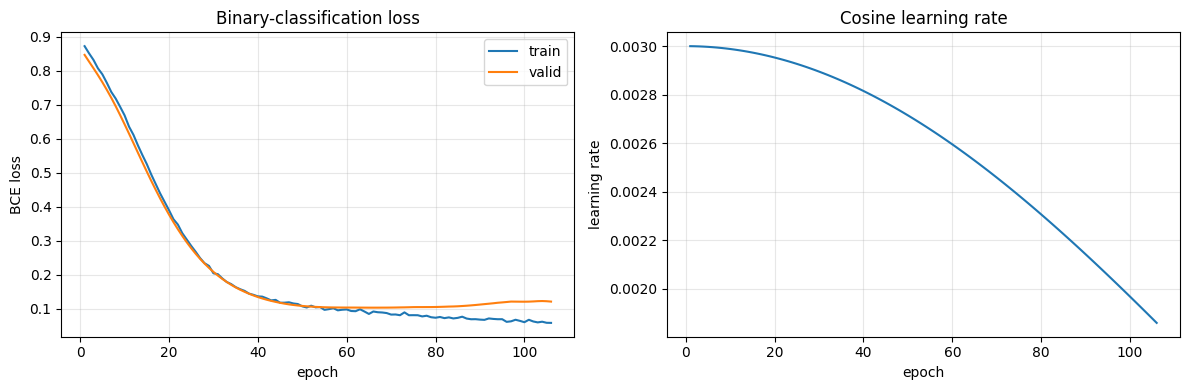

In [28]:
#plot BCE losses and cosine learning rate
epochs_run=range(1,len(history["train"])+1)
fig, axes= plt.subplots(1,2, figsize=(12,4))
axes[0].plot(epochs_run, history["train"], label="train")
axes[0].plot(epochs_run, history["valid"], label="valid")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("BCE loss")
axes[0].set_title("Binary-classification loss")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].plot(epochs_run, history["lr"])
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("learning rate")
axes[1].set_title("Cosine learning rate")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
#convert logits into probabilities
#Now—and only now—we apply sigmoid.
#logit → sigmoid → probability → threshold → class
#We first use threshold 0.50, then choose another threshold using validation cost.

#Produce validation and test probabilities from the restored model.
model.eval()
with torch.inference_mode():
    valid_probability= torch.sigmoid(model(X_val)).squeeze(1).numpy()
    test_probability= torch.sigmoid(model(X_test)).squeeze(1).numpy()

print("Validation Probability min and max", round(valid_probability.min(),4), round(valid_probability.max(),4))
print("Test Probability min and max", round(test_probability.min(),4), round(test_probability.max(),4))
#

Validation Probability min and max 0.0 1.0
Test Probability min and max 0.0 1.0


In [32]:
#Evaluate the model
# For positive class 1 = malignant:
# Precision: out of predicted malignant cases, how many were actually malignant?
# Recall: out of actual malignant cases, how many did we find?
# F1: balance between precision and recall.
# False negative: malignant case predicted benign—important here.
# Accuracy alone is not enough.

# WHAT: Evaluate the test set using the default threshold 0.50.
# WHY: We need class-wise metrics and a confusion matrix, not only accuracy.
# OUTPUT: Accuracy, precision, recall, F1, and classification report.
default_threshold = 0.50
test_prediction_05 = (test_probability >= default_threshold).astype("int64")
print(test_prediction_05)
print("accuracy :", round(accuracy_score(y_test, test_prediction_05), 3))
print("precision:", round(precision_score(y_test, test_prediction_05), 3))
print("recall   :", round(recall_score(y_test, test_prediction_05), 3))
print("F1       :", round(f1_score(y_test, test_prediction_05), 3))
print("\n", classification_report(
    y_test,
    test_prediction_05,
    target_names=["benign", "malignant"],
    digits=3,
))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 1 1 0 0 0 0 1 0 0 1 1 1
 1 0 0 0 0 0 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 0 0 0 1 0 0 1 0 0
 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 1 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 0 0 0 1 0
 0 0 0]
accuracy : 0.991
precision: 1.0
recall   : 0.977
F1       : 0.988

               precision    recall  f1-score   support

      benign      0.986     1.000     0.993        71
   malignant      1.000     0.977     0.988        43

    accuracy                          0.991       114
   macro avg      0.993     0.988     0.991       114
weighted avg      0.991     0.991     0.991       114



rows=actual, columns=predicted
[[71  0]
 [ 1 42]]


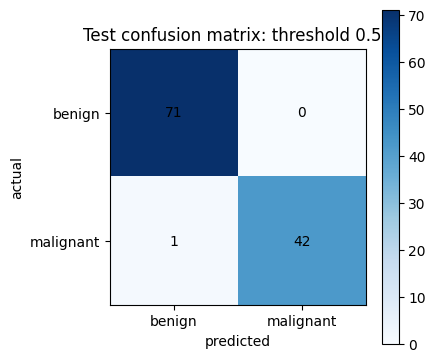

In [34]:
#Draw the confusion matrix at threshold 0.50.
#The matrix shows false positives and false negatives directly.
cm_05 = confusion_matrix(y_test, test_prediction_05, labels=[0, 1])
print("rows=actual, columns=predicted")
print(cm_05)

fig, ax = plt.subplots(figsize=(4.5, 4))
image = ax.imshow(cm_05, cmap="Blues")
ax.set_xticks([0, 1], ["benign", "malignant"])
ax.set_yticks([0, 1], ["benign", "malignant"])
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title("Test confusion matrix: threshold 0.50")

for row in range(2):
    for column in range(2):
        ax.text(column, row, cm_05[row, column], ha="center", va="center")

plt.colorbar(image)
plt.tight_layout()
plt.show()